In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, r2_score

from scipy.sparse import hstack

In [ ]:
df = pd.read_csv("cleaned_with_text.csv")
# target
y = df["listPrice"]

# text feature
text = df["text"].fillna("")

# numeric features
X_num = df.drop(columns=["listPrice", "text"])

In [ ]:
# first split: train (70%) and temp (30%)
X_num_train, X_num_temp, text_train, text_temp, y_train, y_temp = train_test_split(
    X_num, text, y, test_size=0.3, random_state=42
)

# split temp into val (15%) and test (15%)
X_num_val, X_num_test, text_val, text_test, y_val, y_test = train_test_split(
    X_num_temp, text_temp, y_temp, test_size=0.5, random_state=42
)

In [ ]:
# fill missing garage values with 0 (means no garage)
X_num_train["garage"] = X_num_train["garage"].fillna(0)
X_num_val["garage"] = X_num_val["garage"].fillna(0)
X_num_test["garage"] = X_num_test["garage"].fillna(0)

In [ ]:
X_num_train["has_garage"] = (X_num_train["garage"] > 0).astype(int)
X_num_val["has_garage"] = (X_num_val["garage"] > 0).astype(int)
X_num_test["has_garage"] = (X_num_test["garage"] > 0).astype(int)

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_text_train = tfidf.fit_transform(text_train)
X_text_val = tfidf.transform(text_val)
X_text_test = tfidf.transform(text_test)

In [ ]:
X_train = hstack([X_text_train, X_num_train.values])
X_val = hstack([X_text_val, X_num_val.values])
X_test = hstack([X_text_test, X_num_test.values])

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

y_pred_test = rf.predict(X_test)
y_pred_val = rf.predict(X_val)

print("Val R2:", r2_score(y_val, y_pred_val))
print("Val RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_val)))
print("Val MAE:", mean_absolute_error(y_val, y_pred_val))
print()
print("Test R2:", r2_score(y_test, y_pred_test))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))

import joblib
joblib.dump(rf, "rf_with_text_model_fixed_final.pkl")


Val R2: 0.7021987624316987
Val RMSE: 0.3347097168226707
Val MAE: 0.232369653532223

Test R2: 0.6151082338233236
Test RMSE: 0.4013242049113716
Test MAE: 0.24736370910674502
Saved!


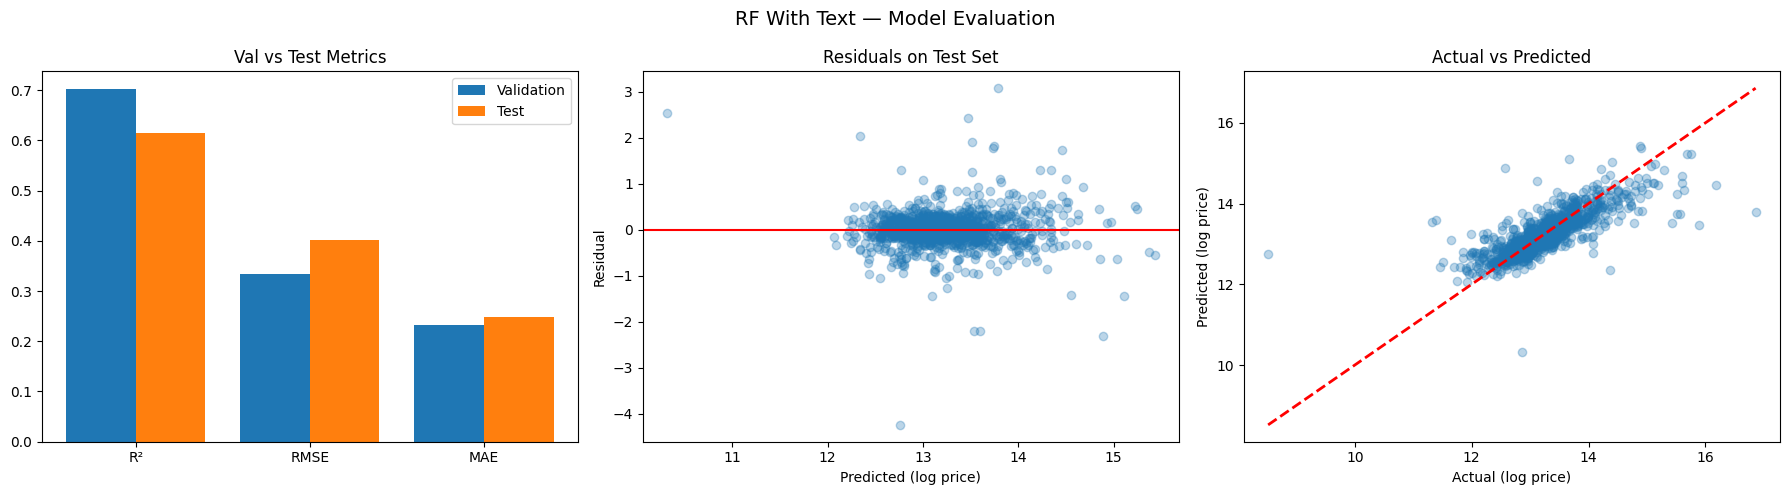

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RF With Text — Model Evaluation', fontsize=14)

# Plot 1 — Val vs Test metrics
metrics = ['R²', 'RMSE', 'MAE']
val_scores = [0.7022, 0.3347, 0.2324]
test_scores = [0.6151, 0.4013, 0.2474]

x = np.arange(len(metrics))
axes[0].bar(x - 0.2, val_scores, 0.4, label='Validation')
axes[0].bar(x + 0.2, test_scores, 0.4, label='Test')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_title('Val vs Test Metrics')
axes[0].legend()

# Plot 2 — Residuals
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.3)
axes[1].axhline(0, color='red')
axes[1].set_title('Residuals on Test Set')
axes[1].set_xlabel('Predicted (log price)')
axes[1].set_ylabel('Residual')

# Plot 3 — Actual vs Predicted
axes[2].scatter(y_test, y_pred_test, alpha=0.3)
axes[2].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_title('Actual vs Predicted')
axes[2].set_xlabel('Actual (log price)')
axes[2].set_ylabel('Predicted (log price)')

plt.tight_layout()
plt.savefig("rf_with_text_evaluation.png")
plt.show()